In [5]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!ls "/content/drive/MyDrive/rgb"

1305031452.791720.png  1305031459.627608.png  1305031466.459790.png
1305031452.823674.png  1305031459.659641.png  1305031466.495809.png
1305031452.859642.png  1305031459.691604.png  1305031466.527538.png
1305031452.891726.png  1305031459.727551.png  1305031466.560353.png
1305031452.923715.png  1305031459.759635.png  1305031466.595936.png
1305031452.959701.png  1305031459.791650.png  1305031466.627549.png
1305031452.991647.png  1305031459.827664.png  1305031466.659688.png
1305031453.023650.png  1305031459.859660.png  1305031466.695822.png
1305031453.059754.png  1305031459.891596.png  1305031466.728074.png
1305031453.091704.png  1305031459.927607.png  1305031466.759637.png
1305031453.123633.png  1305031459.959650.png  1305031466.795604.png
1305031453.159673.png  1305031459.991725.png  1305031466.827879.png
1305031453.191726.png  1305031460.027565.png  1305031466.859665.png
1305031453.223689.png  1305031460.059659.png  1305031466.895694.png
1305031453.259670.png  1305031460.091717.png  13

In [8]:
import glob, os
dataset_path = "/content/drive/MyDrive/rgb"
image;_files = sorted(glob.glob(os.path.join(dataset_path, "*.png")))
print("Total images:", len(image_files))

Total images: 613


In [9]:
!git clone https://github.com/magicleap/SuperGluePretrainedNetwork.git
%cd SuperGluePretrainedNetwork
!ls

Cloning into 'SuperGluePretrainedNetwork'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 185 (delta 0), reused 0 (delta 0), pack-reused 184 (from 2)
Receiving objects: 100% (185/185), 118.85 MiB | 25.65 MiB/s, done.
Resolving deltas: 100% (52/52), done.
/content/SuperGluePretrainedNetwork
assets		   LICENSE	   models     requirements.txt
demo_superglue.py  match_pairs.py  README.md


In [10]:
import torch
import sys
sys.path.append('/content/SuperGluePretrainedNetwork')

from models.matching import Matching
from models.utils import frame2tensor

device = 'cuda' if torch.cuda.is_available() else 'cpu'

config = {
    'superpoint': {
        'nms_radius': 4,
        'keypoint_threshold': 0.005,
        'max_keypoints': 1024
    },
    'superglue': {
        'weights': 'indoor',
        'sinkhorn_iterations': 20,
        'match_threshold': 0.2,
    }
}

matching = Matching(config).eval().to(device)
print("SuperPoint + SuperGlue loaded on", device)

Loaded SuperPoint model
Loaded SuperGlue model ("indoor" weights)
SuperPoint + SuperGlue loaded on cuda


In [11]:
import cv2
import numpy as np
import glob
import os
import pandas as pd

results_sp = []

for i in range(len(image_files) - 1):
    # Read both frames as grayscale
    img1 = cv2.imread(image_files[i], cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image_files[i + 1], cv2.IMREAD_GRAYSCALE)

    # Convert to the tensor format SuperPoint/SuperGlue expects
    frame1_tensor = frame2tensor(img1, device)
    frame2_tensor = frame2tensor(img2, device)

    # Run the full pipeline: detect keypoints in both + match them, all in one call
    with torch.no_grad():
        pred = matching({'image0': frame1_tensor, 'image1': frame2_tensor})

    kpts1 = pred['keypoints0'][0].cpu().numpy()
    kpts2 = pred['keypoints1'][0].cpu().numpy()
    matches_idx = pred['matches0'][0].cpu().numpy()  # for each kpt in img1, index of matched kpt in img2, or -1

    valid = matches_idx > -1
    mkpts1 = kpts1[valid]
    mkpts2 = kpts2[matches_idx[valid]]

    num_matches = len(mkpts1)

    if num_matches < 4:
        results_sp.append((i, i + 1, num_matches, 0))
        continue

    H, mask = cv2.findHomography(mkpts1, mkpts2, cv2.RANSAC, 5.0)
    inliers = int(mask.ravel().sum()) if mask is not None else 0

    results_sp.append((i, i + 1, num_matches, inliers))

    if i % 50 == 0:
        print(f"{i}/{len(image_files)-1} pairs done — matches={num_matches}, inliers={inliers}")

print("Finished all pairs")

0/612 pairs done — matches=364, inliers=341
50/612 pairs done — matches=531, inliers=509
100/612 pairs done — matches=635, inliers=610
150/612 pairs done — matches=644, inliers=593
200/612 pairs done — matches=321, inliers=163
250/612 pairs done — matches=530, inliers=486
300/612 pairs done — matches=208, inliers=199
350/612 pairs done — matches=652, inliers=638
400/612 pairs done — matches=603, inliers=563
450/612 pairs done — matches=404, inliers=386
500/612 pairs done — matches=556, inliers=511
550/612 pairs done — matches=470, inliers=413
600/612 pairs done — matches=724, inliers=710
Finished all pairs


In [12]:
df_sp = pd.DataFrame(results_sp, columns=["Frame_n", "Frame_n+1", "Matches", "Inliers"])
df_sp["Inlier_Ratio"] = df_sp["Inliers"] / df_sp["Matches"].replace(0, pd.NA)

print(df_sp.head(10))
print("\nOverall avg matches:", df_sp["Matches"].mean())
print("Overall avg inliers:", df_sp["Inliers"].mean())
print("Overall avg inlier ratio:", df_sp["Inlier_Ratio"].mean())

df_sp.to_csv("/content/drive/MyDrive/superpoint_superglue_consecutive_pairs.csv", index=False)
print("\nSaved to Drive")

   Frame_n  Frame_n+1  Matches  Inliers  Inlier_Ratio
0        0          1      364      341      0.936813
1        1          2      380      366      0.963158
2        2          3      371      354      0.954178
3        3          4      393      368      0.936387
4        4          5      420      406      0.966667
5        5          6      396      359      0.906566
6        6          7      333      303      0.909910
7        7          8      334      321      0.961078
8        8          9      330      317      0.960606
9        9         10      320      302      0.943750

Overall avg matches: 495.8071895424837
Overall avg inliers: 459.77287581699346
Overall avg inlier ratio: 0.9213140419155288

Saved to Drive


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_sp["Frame_n"], df_sp["Matches"], label="Matches", alpha=0.7)
plt.plot(df_sp["Frame_n"], df_sp["Inliers"], label="Inliers", alpha=0.7)
plt.xlabel("Frame index (n)")
plt.ylabel("Count")
plt.title("SuperPoint + SuperGlue: consecutive-frame matches and inliers")
plt.legend()
plt.savefig("/content/superglue_plot.png", dpi=100, bbox_inches='tight')
plt.close()

print("Saved plot to file")

Saved plot to file


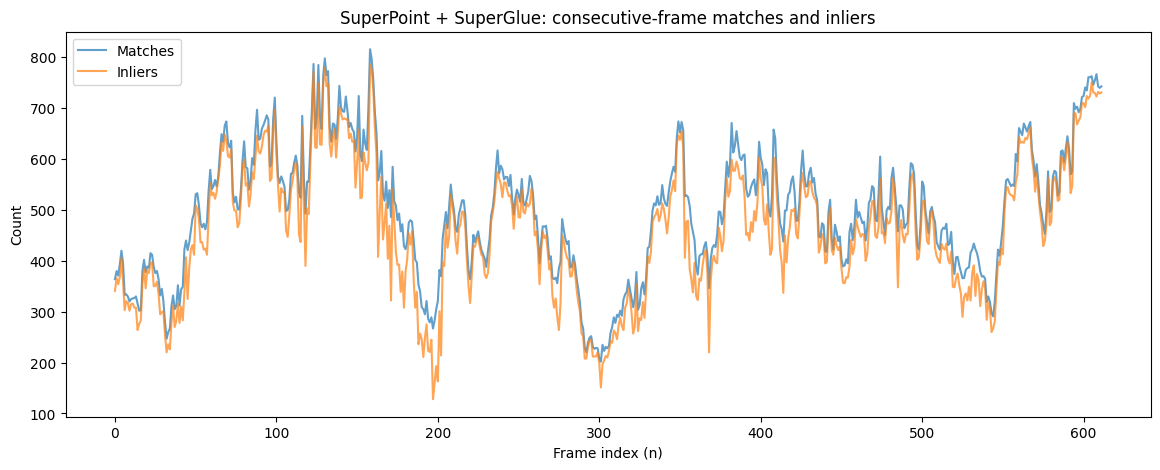

In [14]:
from IPython.display import Image
Image("/content/superglue_plot.png")

In [15]:
print(df_sp["Matches"].mean())

495.8071895424837


In [16]:

import cv2
import warnings
warnings.filterwarnings("ignore")

sp_counts = []
for i in range(0, len(image_files), 10):
    img = cv2.imread(image_files[i], cv2.IMREAD_GRAYSCALE)
    tensor = frame2tensor(img, device)
    with torch.no_grad():
        pred = matching.superpoint({'image': tensor})
    sp_counts.append(len(pred['keypoints'][0]))

print("Avg SuperPoint keypoints (sampled):", sum(sp_counts)/len(sp_counts))

Avg SuperPoint keypoints (sampled): 615.8870967741935
